Notebook 3 - Convex Portfolio Optimisation

In [1]:
from pathlib import Path
root = Path.cwd()
if not (root / "data").is_dir() and (root.parent / "data").is_dir():
    root = root.parent
data = root / "data"

Since sample mean and sample covariance are rather bad ways to estimate expected return in such small time periods like a year, due the large amount of noise, we use the Ledoit-Wolf shrinkage estimator to estimate the covariance matrix.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.covariance import LedoitWolf

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

In [3]:
# Asset returns (simple returns for portfolio accounting)
simplert = pd.read_csv(data / 'processed' / 'simplert.csv', index_col=0, parse_dates=True)
print('Asset returns shape:', simplert.shape)
print('Assets:', simplert.columns.tolist())

# Regime probabilities from HMM
regprobs = pd.read_csv(data / 'processed' / 'regimeprobs.csv', index_col=0, parse_dates=True)
print('\nRegime probabilities shape:', regprobs.shape)
print('Columns:', regprobs.columns.tolist())

simplert.head()

Asset returns shape: (5032, 4)
Assets: ['SPY', 'TLT', 'GLD', 'CASH']

Regime probabilities shape: (4740, 5)
Columns: ['pcrisis', 'precovery', 'pbull', 'regime', 'regimename']


,SPY,TLT,GLD,CASH
Date,,,,
2005-01-04,-0.012219,-0.010481,-0.006509,NaN
2005-01-05,-0.006901,0.005353,-0.001638,0.000081
2005-01-06,0.005085,0.000680,-0.012186,0.000081
2005-01-07,-0.001434,0.002264,-0.007355,0.000081
2005-01-10,0.004728,0.001581,0.002629,0.000081


In [4]:
# The NaN value is due to the fact that it is the first day and the data was created with a lag of one day.
# We can drop this row, as otherwise the Ledoit-Wolf estimator will not work.
simplert = simplert.dropna()
print('After dropping NaN rows:', simplert.shape)


After dropping NaN rows: (5031, 4)


We implement linear programming to find the minimum variance portfolio and the maximum Sharpe ratio portfolio.

In [5]:
def minvarpf(sigma):
    """
    Find portfolio weights minimizing variance.
    
    Parameter(s):
    sigma : np.ndarray, shape (n, n)
        Covariance matrix of asset returns (annualized).

    Return(s):
    w : np.ndarray, shape (n,)
        Optimal weights, sum to 1, all >= 0.
    """
    n = sigma.shape[0]
    w = cp.Variable(n)
    
    objective = cp.Minimize(cp.quad_form(w, sigma))
    constraints = [
        cp.sum(w) == 1,   # fully invested
        w >= 0,           # long-only
    ]
    
    problem = cp.Problem(objective, constraints)
    problem.solve()
    
    if problem.status != 'optimal':
        raise RuntimeError(f'Solver failed: {problem.status}')
    
    return w.value

In [6]:
def maxsharpepf(mu, sigma):
    """
    Find portfolio weights maximizing the Sharpe ratio using convex reformulation.
    
    Parameter(s)
    mu : np.ndarray, shape (n,)
        Expected returns (annualized).
    sigma : np.ndarray, shape (n, n)
        Covariance matrix (annualized).
    
    Return(s):
    w : np.ndarray, shape (n,)
        Optimal weights, sum to 1, all >= 0.
    """
    n = len(mu)
    
    # If all expected returns are <= 0, max-sharpe is undefined and we fall back to min variance.
    if np.max(mu) <= 0:
        return minvarpf(sigma)
    
    y = cp.Variable(n)
    
    objective = cp.Minimize(cp.quad_form(y, sigma))
    constraints = [
        mu @ y == 1,
        y >= 0,
    ]
    
    problem = cp.Problem(objective, constraints)
    problem.solve()
    
    if problem.status != 'optimal':
        # Fall back to min variance if the reformulation fails
        return minvarpf(sigma)
    
    # Recover weights by normalizing y to sum to 1
    w = y.value / np.sum(y.value)
    return w

In [7]:
def eqwtpf(nassets):
    return np.ones(nassets) / nassets

In [8]:
# As a sample run, we take the last 252 days of asset returns.

window = simplert.iloc[-252:]
assets = window.columns.tolist()
print('Window:', window.index[0].date(), 'to', window.index[-1].date())

mu = window.mean().values * 252       
Sigma_sample = window.cov().values * 252


lw = LedoitWolf().fit(window.values)
Sigma = lw.covariance_ * 252

print('\nAnnualized expected returns:')
for a, m in zip(assets, mu):
    print(f'  {a}: {m*100:+.1f}%')

print('\nAnnualized volatilities (sqrt of diagonal):')
for a, s in zip(assets, np.sqrt(np.diag(Sigma))):
    print(f'  {a}: {s*100:.1f}%')


wminvar = minvarpf(Sigma)
wmaxsr  = maxsharpepf(mu, Sigma)
wew     = eqwtpf(len(assets))

results = pd.DataFrame({
    'Min Variance': wminvar,
    'Max Sharpe':   wmaxsr,
    'Equal Weight': wew,
}, index=assets).round(3)

print('\nOptimal portfolios:')
print(results)

Window: 2024-01-02 to 2024-12-31

Annualized expected returns:
  SPY: +23.0%
  TLT: -7.4%
  GLD: +24.8%
  CASH: +5.3%

Annualized volatilities (sqrt of diagonal):
  SPY: 12.5%
  TLT: 14.0%
  GLD: 14.8%
  CASH: 3.2%

Optimal portfolios:
      Min Variance  Max Sharpe  Equal Weight
SPY          0.049       0.169          0.25
TLT          0.039       0.000          0.25
GLD          0.024       0.122          0.25
CASH         0.888       0.709          0.25


In [9]:
# Sanity Check
def portfolio_stats(w, mu, sigma):
    """Annualized return, vol, sharpe."""
    ret = w @ mu
    vol = np.sqrt(w @ sigma @ w)
    sharpe = ret / vol if vol > 0 else 0
    return ret, vol, sharpe

print('Portfolio statistics (annualized):')
print(f'{"Strategy":<15} {"Return":>10} {"Vol":>8} {"Sharpe":>11}')
for name, w in [('Min Variance', wminvar), ('Max Sharpe', wmaxsr), ('Equal Weight', wew)]:
    r, v, s = portfolio_stats(w, mu, Sigma)
    print(f'{name:<15} {r*100:>8.1f}% {v*100:>8.1f}% {s:>10.2f}')

Portfolio statistics (annualized):
Strategy            Return      Vol      Sharpe
Min Variance         6.1%      3.0%       2.02
Max Sharpe          10.6%      3.9%       2.76
Equal Weight        11.4%      7.0%       1.64


In [10]:
def estregimeparams(returns, regimeseries, minobs=60):
    """
    Estimate mu and sigma separately for each regime.
    
    Parameter(s)
    returns : pd.DataFrame
        Simple returns for each asset.
    regimeseries : pd.Series
        Hard regime labels (0 = Crisis, 1 = Recovery, 2 = Bullish).
    minobs : int
        Minimum observations required. Falls back to full sample if insufficient.
    
    Return(s)
    dict: {regid: {'mu': array, 'sigma': array}}
    """
    regimeparams = {}
    regimenames = {0: 'Crisis', 1: 'Recovery', 2: 'Bullish'}
    
    # Align returns and regime labels on common dates
    commonidx = returns.index.intersection(regimeseries.index)
    returnsaligned = returns.loc[commonidx]
    regimealigned  = regimeseries.loc[commonidx]
    
    # Full-sample fallback estimates
    lw_full = LedoitWolf().fit(returnsaligned.values)
    mu_full = returnsaligned.mean().values * 252
    Sigma_full = lw_full.covariance_ * 252
    
    for regid, name in regimenames.items():
        mask = regimealigned == regid
        regimereturns = returnsaligned[mask]
        nobs = len(regimereturns)
        
        print(f'{name}: {nobs} observations', end='')
        
        if nobs >= minobs:
            mu = regimereturns.mean().values * 252
            lw = LedoitWolf().fit(regimereturns.values)
            sigma = lw.covariance_ * 252
            print(' - regime-specific estimate')
        else:
            mu = mu_full
            sigma = Sigma_full
            print(f' - too few obs, using full sample fallback')
        
        regimeparams[regid] = {'mu': mu, 'sigma': sigma}
    
    return regimeparams


regimeparams = estregimeparams(simplert, regprobs['regime'])

Crisis: 1171 observations - regime-specific estimate
Recovery: 1547 observations - regime-specific estimate
Bullish: 2022 observations - regime-specific estimate


In [11]:
assets = simplert.columns.tolist()
regimenames = {0: 'Crisis', 1: 'Recovery', 2: 'Bullish'}

print('\nRegime based annualized expected returns:')
print(f'{"Asset":<8}', end='')
for name in regimenames.values():
    print(f'{name:>12}', end='')
print()
for i, asset in enumerate(assets):
    print(f'{asset:<8}', end='')
    for regid in regimenames:
        mu_val = regimeparams[regid]['mu'][i] * 100
        print(f'{mu_val:>+11.1f}%', end='')
    print()


Regime based annualized expected returns:
Asset         Crisis    Recovery     Bullish
SPY           -14.1%      +24.1%      +17.5%
TLT            +9.2%       +4.7%       +0.6%
GLD           +13.0%       +6.4%       +9.3%
CASH           +1.2%       +0.1%       +2.7%


In [12]:
def getregimepfs(regparams):
    """
    Compute the optimal portfolio for each regime.
    
    Regime mapping:
        0 = Crisis - Min Variance (capital preservation)
        1 = Recovery - Max Sharpe   (aggressive high risk)
        2 = Bullish - Max Sharpe   (steady growth)
    
    Returns
    -------
    dict: {regid: wtarr}
    """
    regimepfs = {}
    
    for regid, params in regparams.items():
        mu    = params['mu']
        sigma = params['sigma']
        name  = regimenames[regid]
        
        if regid == 0:    # Crisis - Min Variance
            w = minvarpf(sigma)
            strategy = 'Min Variance'
        else:                  # Recovery + Bullish - Max Sharpe
            w = maxsharpepf(mu, sigma)
            strategy = 'Max Sharpe'
        
        regimepfs[regid] = w
        print(f'{name} ({strategy}):')
        for asset, wt in zip(assets, w):
            print(f'    {asset}: {wt:.1%}')
        print()
    
    return regimepfs

regimepfs = getregimepfs(regimeparams)

Crisis (Min Variance):
    SPY: 1.6%
    TLT: 3.2%
    GLD: 1.3%
    CASH: 93.9%

Recovery (Max Sharpe):
    SPY: 57.5%
    TLT: 33.5%
    GLD: 0.0%
    CASH: 9.0%

Bullish (Max Sharpe):
    SPY: 6.1%
    TLT: 0.1%
    GLD: 1.5%
    CASH: 92.4%



In [13]:
def blendpfs(regprobsrow, regimepfs):
    """
    Blend regime-optimal portfolios weighted by regime probabilities.
    
    Parameter(s)
    regprobsrow : array-like, shape (3,)
        [pcrisis, precovery, pbull]
    regimepfs : dict
        {regid: wtarr}
    
    Return(s)
    w : np.ndarray
        Blended portfolio weights, sum to 1.
    """
    pcrisis, precovery, pbull = regprobsrow
    
    w = (pcrisis * regimepfs[0] + precovery * regimepfs[1] + pbull * regimepfs[2])
    w = w / w.sum()
    return w

# Test it on a few regime probability scenarios
testcases = {
    'Pure Crisis    ': [1.0, 0.0, 0.0],
    'Pure Recovery  ': [0.0, 1.0, 0.0],
    'Pure Bull      ': [0.0, 0.0, 1.0],
    'Uncertain (equal)': [0.33, 0.33, 0.34],
    'Transitioning  ': [0.2, 0.5, 0.3],
}

print('Blended portfolios under different regime scenarios:')
print(f'{"Scenario":<21}', end='')
for a in assets:
    print(f'{a:>7}', end='')
print()

for case, probs in testcases.items():
    w = blendpfs(probs, regimepfs)
    print(f'{case:<22}', end='')
    for wt in w:
        print(f'{wt:>7.1%}', end='')
    print()

Blended portfolios under different regime scenarios:
Scenario                 SPY    TLT    GLD   CASH
Pure Crisis              1.6%   3.2%   1.3%  93.9%
Pure Recovery           57.5%  33.5%   0.0%   9.0%
Pure Bull                6.1%   0.1%   1.5%  92.4%
Uncertain (equal)       21.6%  12.1%   0.9%  65.4%
Transitioning           30.9%  17.4%   0.7%  51.0%


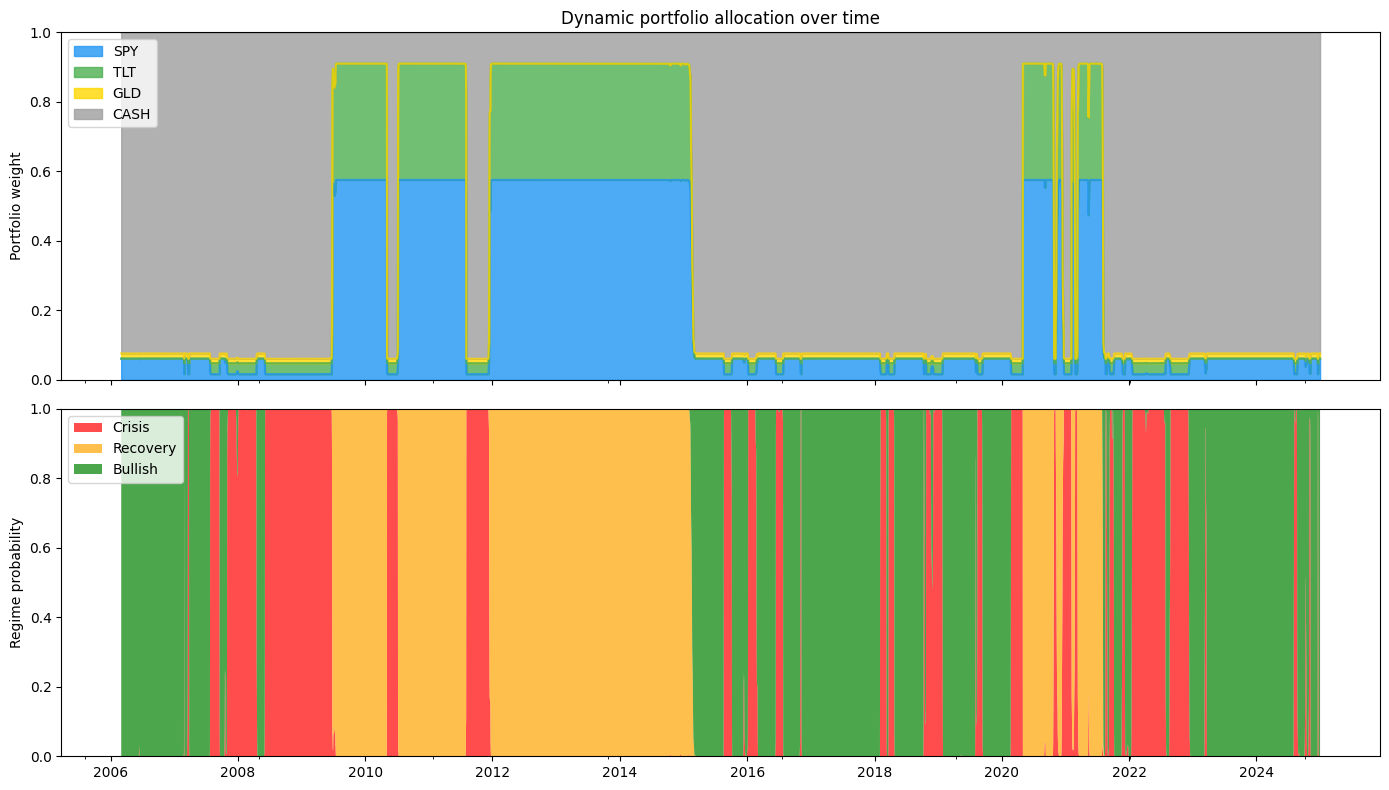

In [14]:
commonidx = simplert.index.intersection(regprobs.index)
rp = regprobs.loc[commonidx]

# Compute blended portfolio for every day in history
daily_weights = []
for date, row in rp.iterrows():
    probs = [row['pcrisis'], row['precovery'], row['pbull']]
    w = blendpfs(probs, regimepfs)
    daily_weights.append(w)

weights_df = pd.DataFrame(
    daily_weights,
    index=rp.index,
    columns=assets
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Stacked area chart of weights
weights_df.plot.area(
    ax=axes[0],
    stacked=True,
    color=['#2196F3', '#4CAF50', '#FFD700', '#9E9E9E'],
    alpha=0.8
)
axes[0].set_title('Dynamic portfolio allocation over time')
axes[0].set_ylabel('Portfolio weight')
axes[0].legend(loc='upper left')
axes[0].set_ylim(0, 1)

axes[1].stackplot(
    rp.index,
    rp['pcrisis'], rp['precovery'], rp['pbull'],
    labels=['Crisis', 'Recovery', 'Bullish'],
    colors=['red', 'orange', 'green'],
    alpha=0.7
)
axes[1].set_ylabel('Regime probability')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left')

import matplotlib.dates as mdates
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()